### Libraries

In [1]:
import pandas as pd
import pandas as pd
import tensorflow as tf

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import accuracy_score, auc, roc_curve
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
import seaborn as sns

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

### Setup

In [4]:
train_df = pd.read_csv('C:\\Users\\User\\ODL_Labs\\Assignment\\data\\train_churn_dataset.csv')
val_df = pd.read_csv('C:\\Users\\User\\ODL_Labs\\Assignment\\data\\val_churn_dataset.csv')
test_df = pd.read_csv('C:\\Users\\User\\ODL_Labs\\Assignment\\data\\test_churn_dataset.csv')

In [5]:
X_train = train_df.drop(columns=['Churn'])
y_train = train_df['Churn']

In [6]:
X_val = val_df.drop(columns=['Churn'])
y_val = val_df['Churn']

In [7]:
X_test = test_df.drop(columns=['Churn'])
y_test = test_df['Churn']

In [8]:
print("Training set size:", len(X_train))
print("Validation set size:", len(X_val))
print("Test set size:", len(X_test))

# Distribution of labels in the training set
train_labels = y_train.values

print("\nTraining set label distribution:")
print(pd.Series(train_labels).value_counts(normalize=True))

Training set size: 314599
Validation set size: 67414
Test set size: 67415

Training set label distribution:
1    0.500002
0    0.499998
Name: proportion, dtype: float64


### Model Training

In [9]:
# Code for CNN here
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

# Reshape data for Conv1D (add sequence dimension)
X_train_reshaped = X_train.values.reshape((X_train.shape[0], X_train.shape[1], 1)) if isinstance(X_train, pd.DataFrame) else X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val_reshaped = X_val.values.reshape((X_val.shape[0], X_val.shape[1], 1)) if isinstance(X_val, pd.DataFrame) else X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

In [11]:
# Build CNN model
model = Sequential([
    Input(shape=(X_train_reshaped.shape[1], 1)),
    Conv1D(32, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

In [12]:
# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

model.summary()

# Train with reshaped data
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 12, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 6, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 6, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,801 (81.25 KB)

 Trainable params: 20,801 (81.25 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
9832/9832 ━━━━━━━━━━━━━━━━━━━━ 38s 4ms/step - AUC: 0.9412 - accuracy: 0.9057 - loss: 0.2668 - val_AUC: 0.9473 - val_accuracy: 0.9150 - val_loss: 0.2391
Epoch 2/30
9832/9832 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step - AUC: 0.9477 - accuracy: 0.9177 - loss: 0.2339 - val_AUC: 0.9486 - val_accuracy: 0.9146 - val_loss: 0.2333
Epoch 3/30
9832/9832 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - AUC: 0.9493 - accuracy: 0.9198 - loss: 0.2257 - val_AUC: 0.9498 - val_accuracy: 0.9194 - val_loss: 0.2215
Epoch 4/30
9832/9832 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - AUC: 0.9508 - accuracy: 0.9212 - loss: 0.2204 - val_AUC: 0.9507 - val_accuracy: 0.9202 - val_loss: 0.2201
Epoch 5/30
9832/9832 ━━━━━━━━━━━━━━━━━━━━ 40s 4ms/step - AUC: 0.9515 - accuracy: 0.9220 - loss: 0.2166 - val_AUC: 0.9503 - val_accuracy: 0.9193 - val_loss: 0.2190
Epoch 6/30
9832/9832 ━━━━━━━━━━━━━━━━━━━━ 41s 4ms/step - AUC: 0.9518 - accuracy: 0.9225 - loss: 0.2144 - val_AUC: 0.9503 - val_accuracy: 0.9216 - val_loss: 0.2164
Epoch 7/30
9832/9832 ━

### Model Evaluation

In [14]:
# Test the model on the test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

2107/2107 ━━━━━━━━━━━━━━━━━━━━ 2s 751us/step


In [15]:
# Classification report
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

accuracy = accuracy_score(y_test, y_pred)
precision = report["1"]["precision"]
recall = report["1"]["recall"]
f1 = report["1"]["f1-score"]

print(f"CLASSIFICATION REPORT:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

CLASSIFICATION REPORT:
Accuracy: 0.9249425202106356
Precision: 0.8737377690802348
Recall: 0.9934434983831252
F1-score: 0.9297534429142603


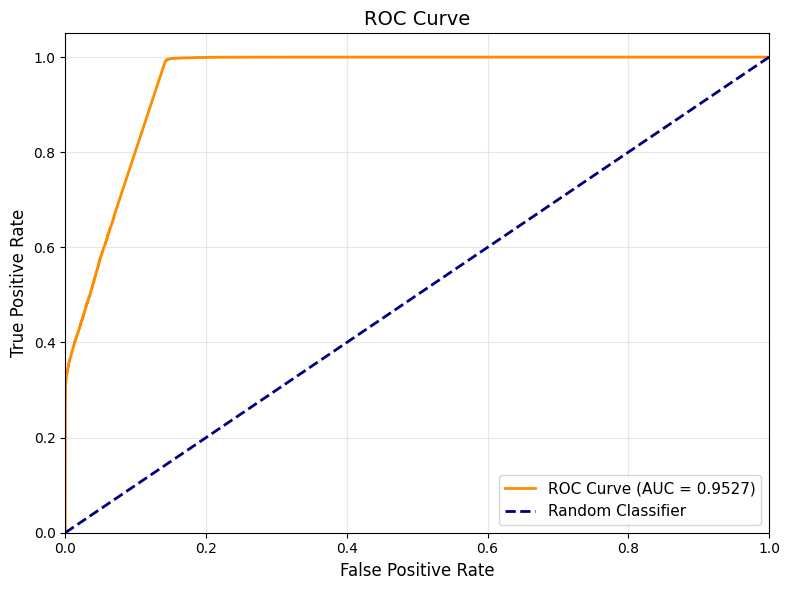

AUC Score: 0.9527


In [16]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Calculate AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('roc_auc_curve.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

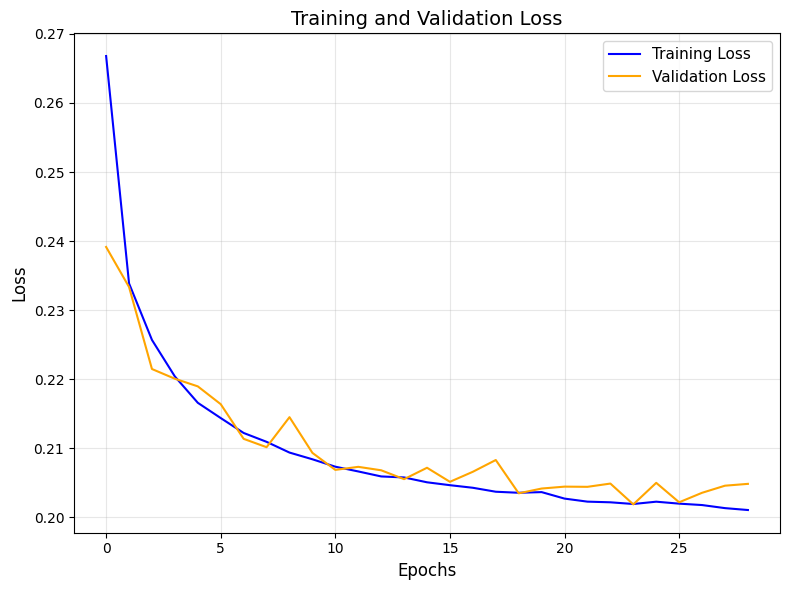

In [17]:
# Training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()


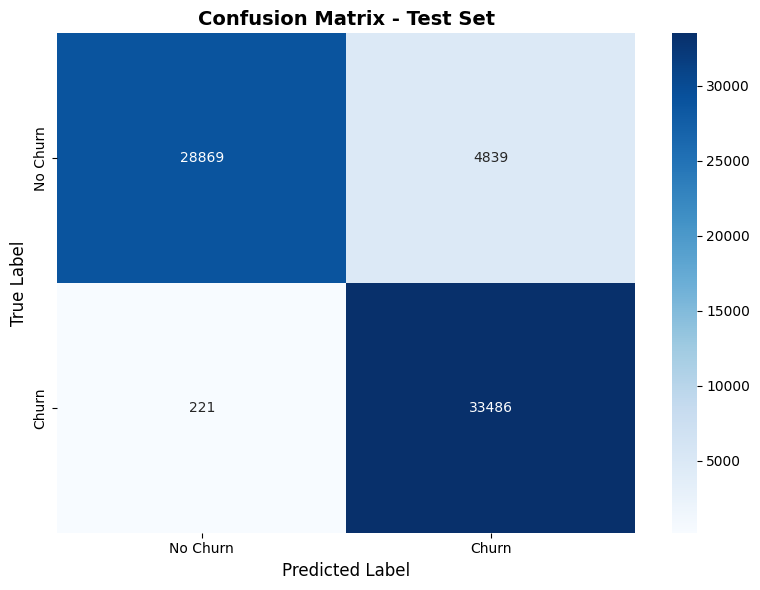

In [18]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
 
# Create the plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,  # Show numbers in cells
    fmt='d',     # Format as integers
    cmap='Blues',  # Color palette
    cbar=True,   # Show color bar
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)
 
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()